# Operational Efficiency Analysis for Delivery and Logistics

**Project Objective:** Comprehensive analysis of logistics operations to identify inefficiencies, optimize costs, and improve delivery performance

This project analyzes logistics and delivery operations to evaluate performance, identify inefficiencies, and provide actionable insights to improve delivery speed, reduce delays, and optimize operational costs.

## Business Problem

Many logistics operations struggle with:
- **Delayed deliveries** affecting customer satisfaction and retention
- **Inconsistent service levels** across different regions and carriers
- **Rising operational costs** reducing profit margins

**Goals:**
1. Identify root causes of delivery delays
2. Compare performance across carriers and regions
3. Analyze cost-efficiency relationships
4. Generate actionable recommendations for improvement

In [ ]:
# ============================================================================
# SECTION 1: SETUP AND DATA IMPORT
# ============================================================================
# Install required data manipulation libraries
!pip install pandas numpy

In [ ]:
# Install visualization libraries for creating charts and heatmaps
!pip install matplotlib seaborn

In [3]:
# Import essential libraries for data analysis and visualization
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical computations
import matplotlib.pyplot as plt  # Static data visualization
import seaborn as sns        # Statistical data visualization

# Configure plotting style for better-looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Data Overview

This section loads and explores the logistics dataset to understand its structure and content.

In [4]:
# Load logistics dataset from CSV file
df = pd.read_csv('logistics_dataset.csv')

# Display first few rows to understand data structure
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,shipment_id,order_date,dispatch_date,promised_delivery_date,delivery_date,region,city,customer_type,shipment_type,carrier,...,distance_km,shipping_cost,order_value,delivery_status,delay_days,customer_rating,delivery_time_days,on_time_flag,cost_per_km,cost_per_kg
0,1,4/24/2024,4/26/2024,5/2/2024,5/2/2024,Central,Riyadh,VIP,Standard,AramexPlus,...,208,24.90,76.14,Delivered,0,4,6,1,0.119712,4.422735
1,2,2/14/2024,2/16/2024,2/18/2024,2/18/2024,Western,Madinah,Retail,Express,FastGo,...,328,62.38,101.09,Delivered,0,5,2,1,0.190183,2.312083
2,3,2/17/2024,2/18/2024,2/19/2024,2/19/2024,Southern,Jizan,Retail,Same-Day,FastGo,...,352,58.91,2299.37,Delivered,0,4,1,1,0.167358,15.301299
3,4,4/11/2024,4/13/2024,4/17/2024,4/17/2024,Western,Jeddah,VIP,Standard,FastGo,...,465,35.49,1476.52,Delivered,0,4,4,1,0.076323,12.675000
4,5,10/28/2024,10/30/2024,11/2/2024,11/4/2024,Southern,Jizan,Business,Standard,PrimeRoute,...,266,38.85,639.58,Delayed,2,4,5,0,0.146053,3.425926


In [5]:
# Check dataset dimensions (rows and columns)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)

Dataset shape: 3000 rows, 22 columns

Column names and types:
shipment_id                 int64
order_date                 object
dispatch_date              object
promised_delivery_date     object
delivery_date              object
region                     object
city                       object
customer_type              object
shipment_type              object
carrier                    object
product_category           object
weight_kg                 float64
distance_km                 int64
shipping_cost             float64
order_value               float64
delivery_status            object
delay_days                  int64
customer_rating             int64
delivery_time_days          int64
on_time_flag                int64
cost_per_km               float64
cost_per_kg               float64
dtype: object


---

## SECTION 2: GEOGRAPHIC PERFORMANCE ANALYSIS

### Regional Delays Analysis
This section analyzes delivery delays by geographic region to identify which areas face the most significant delay issues.

Average Delay Days by Region:
region
Southern    2.085616
Northern    1.890344
Eastern     0.740000
Western     0.631068
Central     0.473595
Name: delay_days, dtype: float64



C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\4123920784.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="region", y="delay_days", data=df, palette="YlOrRd")


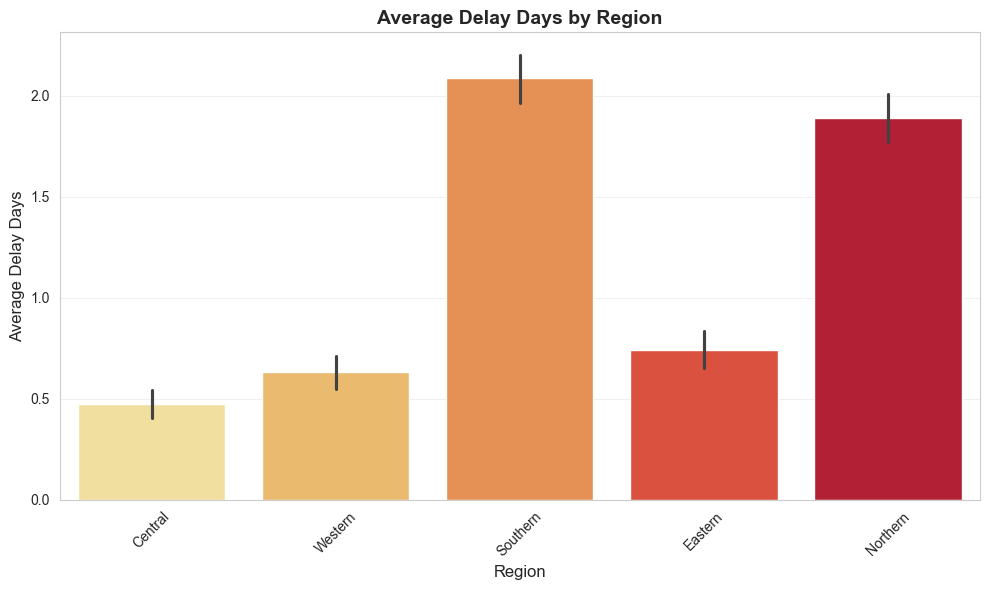

Insight: Regions with higher average delays are facing operational challenges.
These regions may need additional resources or process improvements.


In [6]:
# Calculate average delay days by region
regional_delays = df.groupby("region")["delay_days"].mean().sort_values(ascending=False)
print("Average Delay Days by Region:")
print(regional_delays)
print()

# Visualize regional delays with bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="region", y="delay_days", data=df, palette="YlOrRd")
plt.title("Average Delay Days by Region", fontsize=14, fontweight='bold')
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average Delay Days", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight: Regions with higher average delays are facing operational challenges.")
print("These regions may need additional resources or process improvements.")

---

## SECTION 3: CARRIER PERFORMANCE ANALYSIS

### Carrier Delay Comparison
Analyzing performance metrics across different shipping carriers to identify top and underperforming carriers.

Average Delay Days by Carrier:
carrier
LocalShip     2.052430
AramexPlus    1.400832
PrimeRoute    0.774667
FastGo        0.386881
Name: delay_days, dtype: float64



C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\2244307093.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="carrier", y="delay_days", data=df, palette="RdYlGn_r")


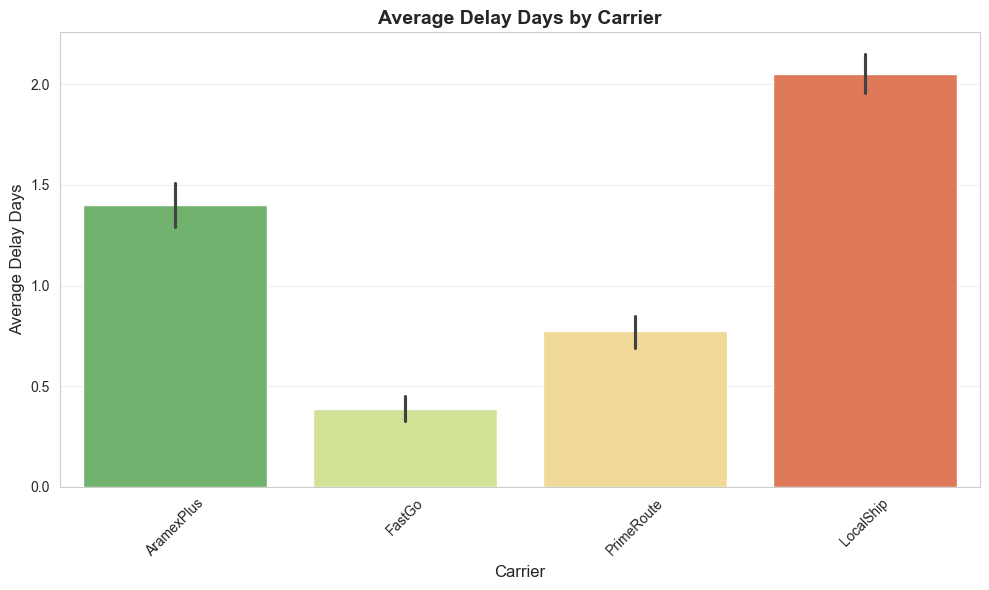

Key Finding: Significant variations in delay performance across carriers.
This suggests different operational capabilities and service quality levels.


In [7]:
# Calculate average delays by carrier
carrier_delays = df.groupby("carrier")["delay_days"].mean().sort_values(ascending=False)
print("Average Delay Days by Carrier:")
print(carrier_delays)
print()

# Create visualization for carrier performance comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="carrier", y="delay_days", data=df, palette="RdYlGn_r")
plt.title("Average Delay Days by Carrier", fontsize=14, fontweight='bold')
plt.xlabel("Carrier", fontsize=12)
plt.ylabel("Average Delay Days", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Finding: Significant variations in delay performance across carriers.")
print("This suggests different operational capabilities and service quality levels.")

---

## SECTION 4: SHIPMENT TYPE AND COST ANALYSIS

### Cost Analysis by Shipment Type
Understanding how different shipment types (Express, Standard, Same-Day) affect shipping costs and delivery times.

Average Shipping Cost by Shipment Type:
shipment_type
Same-Day    61.653200
Express     50.787543
Standard    38.832636
Name: shipping_cost, dtype: float64



C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\2336457408.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="shipment_type", y="shipping_cost", data=df, palette="viridis")


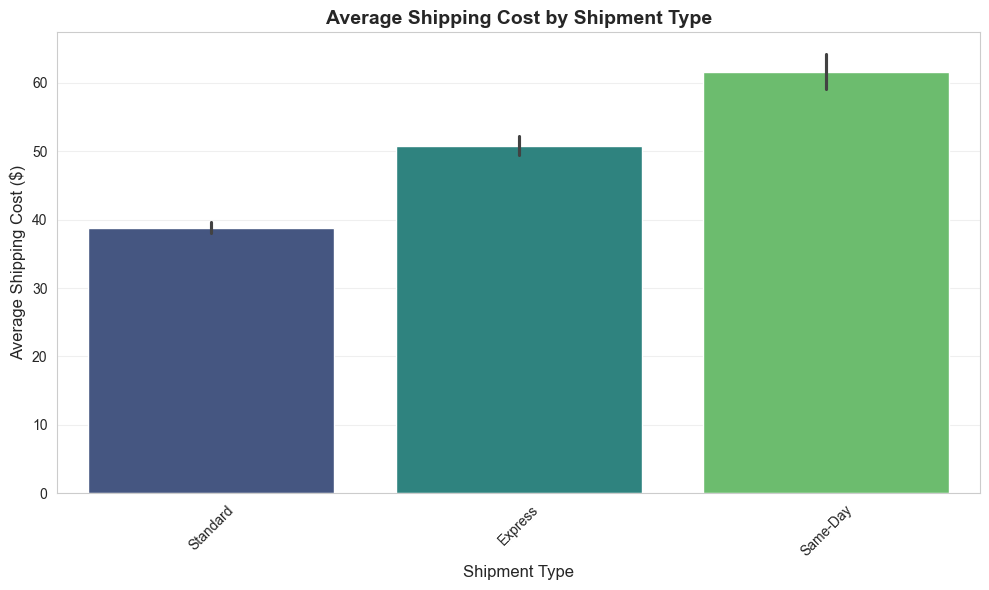

Observation: Premium shipment types command higher costs.
Next, we'll analyze if higher costs correlate with better delivery performance.


In [8]:
# Calculate average shipping cost by shipment type
cost_by_type = df.groupby("shipment_type")["shipping_cost"].mean().sort_values(ascending=False)
print("Average Shipping Cost by Shipment Type:")
print(cost_by_type)
print()

# Visualize cost differences across shipment types
plt.figure(figsize=(10, 6))
sns.barplot(x="shipment_type", y="shipping_cost", data=df, palette="viridis")  
plt.title("Average Shipping Cost by Shipment Type", fontsize=14, fontweight='bold')
plt.xlabel("Shipment Type", fontsize=12)
plt.ylabel("Average Shipping Cost ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: Premium shipment types command higher costs.")
print("Next, we'll analyze if higher costs correlate with better delivery performance.")

Average Delay Days by Shipment Type:
shipment_type
Express     0.802048
Same-Day    0.986667
Standard    1.364086
Name: delay_days, dtype: float64



C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\279076949.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="shipment_type", y="delay_days", data=df, palette="coolwarm")


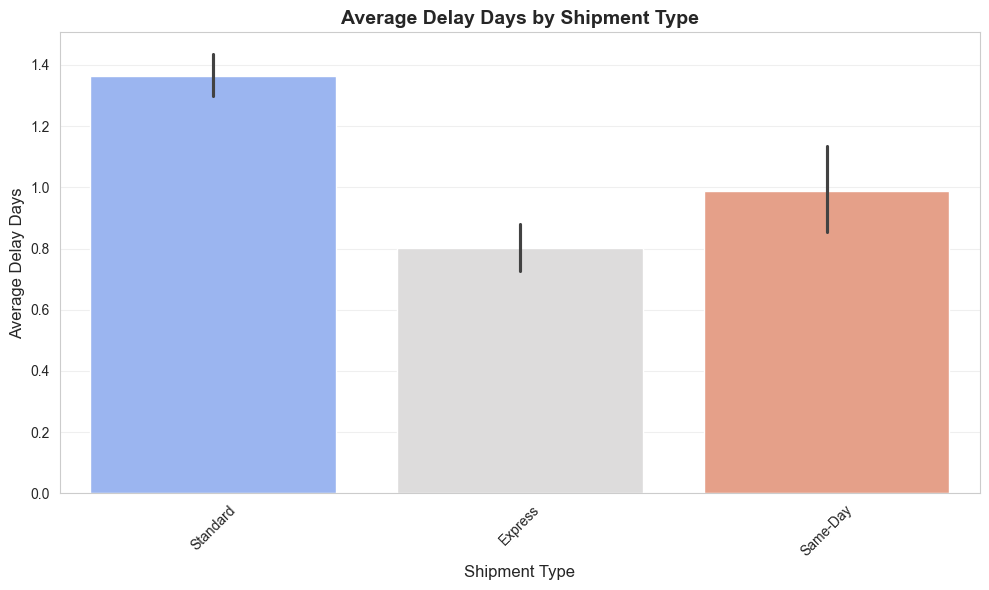

Finding: Higher-tier shipment services show reduced delays.
This validates the cost-performance relationship.


In [9]:
# Analyze delay performance by shipment type
delay_by_type = df.groupby("shipment_type")["delay_days"].mean().sort_values(ascending=True)
print("Average Delay Days by Shipment Type:")
print(delay_by_type)
print()

# Create visualization to compare delays across shipment types
plt.figure(figsize=(10, 6))
sns.barplot(x="shipment_type", y="delay_days", data=df, palette="coolwarm")
plt.title("Average Delay Days by Shipment Type", fontsize=14, fontweight='bold')
plt.xlabel("Shipment Type", fontsize=12)
plt.ylabel("Average Delay Days", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Finding: Higher-tier shipment services show reduced delays.")
print("This validates the cost-performance relationship.")

---

### Cross-Dimensional Performance Matrix
Examining how carriers perform differently across regions and identifying risk zones.

Average Delay Days - Region & Carrier Matrix:
carrier   AramexPlus    FastGo  LocalShip  PrimeRoute
region                                               
Central     0.564885  0.031847   1.078788    0.156716
Eastern     0.925170  0.073333   1.719424    0.353659
Northern    2.386667  0.813333   2.973684    1.402516
Southern    2.503704  1.088889   2.880240    1.714286
Western     0.658228  0.025806   1.603774    0.184932



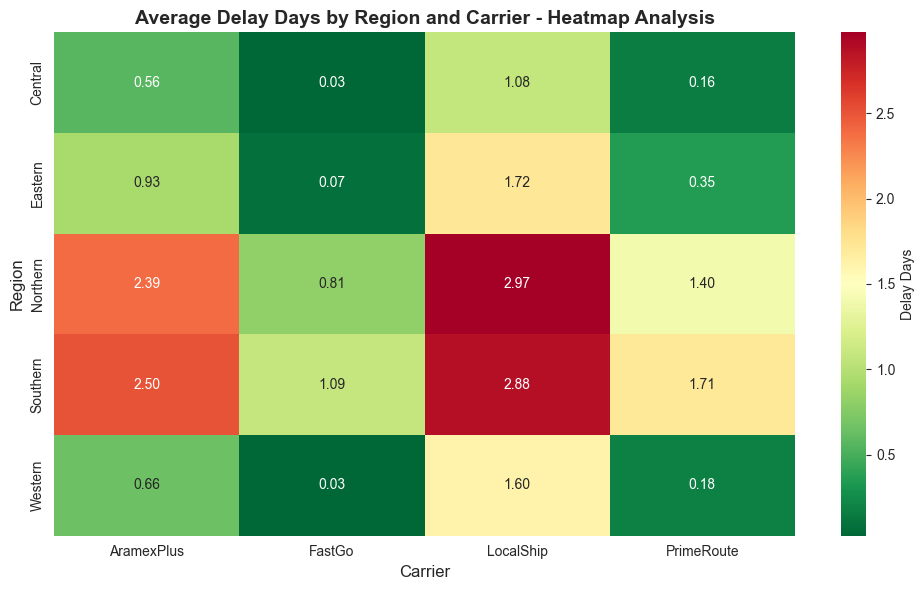

Heatmap Interpretation:
- Red zones (high values) indicate problematic carrier-region combinations
- Green zones (low values) show areas of operational excellence
- Use this to identify where to focus improvement efforts first


In [ ]:
# Create a pivot table showing average delays by region and carrier combination
pivot = df.groupby(["region", "carrier"])["delay_days"].mean().unstack()
print("Average Delay Days - Region & Carrier Matrix:")
print(pivot)
print()

# Create heatmap visualization to identify performance patterns
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", cbar_kws={'label': 'Delay Days'})
plt.title("Average Delay Days by Region and Carrier - Heatmap Analysis", fontsize=14, fontweight='bold')
plt.ylabel("Region", fontsize=12)
plt.xlabel("Carrier", fontsize=12)
plt.tight_layout()
plt.show()

print("Heatmap Interpretation:")
print("- Red zones (high values) indicate problematic carrier-region combinations")
print("- Green zones (low values) show areas of operational excellence")
print("- Use this to identify where to focus improvement efforts first")

---

## SECTION 5: FACTOR CORRELATION ANALYSIS

### Distance and Weight Impact on Delays
Analyzing how physical shipment characteristics (distance, weight) correlate with delivery delays.

In [11]:
# Calculate correlation between distance and delay days
distance_delay_corr = df[["distance_km", "delay_days"]].corr()
print("Correlation Analysis: Distance vs Delay Days")
print(distance_delay_corr)
print(f"\nCorrelation coefficient: {distance_delay_corr.iloc[0, 1]:.4f}")
print("Interpretation: Positive correlation indicates longer distances tend to have longer delays")

Correlation Analysis: Distance vs Delay Days
             distance_km  delay_days
distance_km     1.000000    0.532221
delay_days      0.532221    1.000000

Correlation coefficient: 0.5322
Interpretation: Positive correlation indicates longer distances tend to have longer delays


In [12]:
# Calculate correlation between weight and delay days
weight_delay_corr = df[["weight_kg", "delay_days"]].corr()
print("Correlation Analysis: Weight vs Delay Days")
print(weight_delay_corr)
print(f"\nCorrelation coefficient: {weight_delay_corr.iloc[0, 1]:.4f}")
print("Interpretation: Positive correlation indicates heavier shipments tend to have longer delays")

Correlation Analysis: Weight vs Delay Days
            weight_kg  delay_days
weight_kg    1.000000    0.312144
delay_days   0.312144    1.000000

Correlation coefficient: 0.3121
Interpretation: Positive correlation indicates heavier shipments tend to have longer delays


---

### Distance-Segmented Performance Analysis
Breaking down delay patterns by distance ranges to identify critical distance thresholds.

Average Delay Days by Distance Segment:
distance_bucket
0-100 km      0.212329
100-300 km    0.656627
300-600 km    1.250000
600+ km       2.582627
Name: delay_days, dtype: float64



C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\681063599.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_segments = df.groupby("distance_bucket")["delay_days"].mean().sort_values()
C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\681063599.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="distance_bucket", y="delay_days", data=df, palette="YlGnBu")


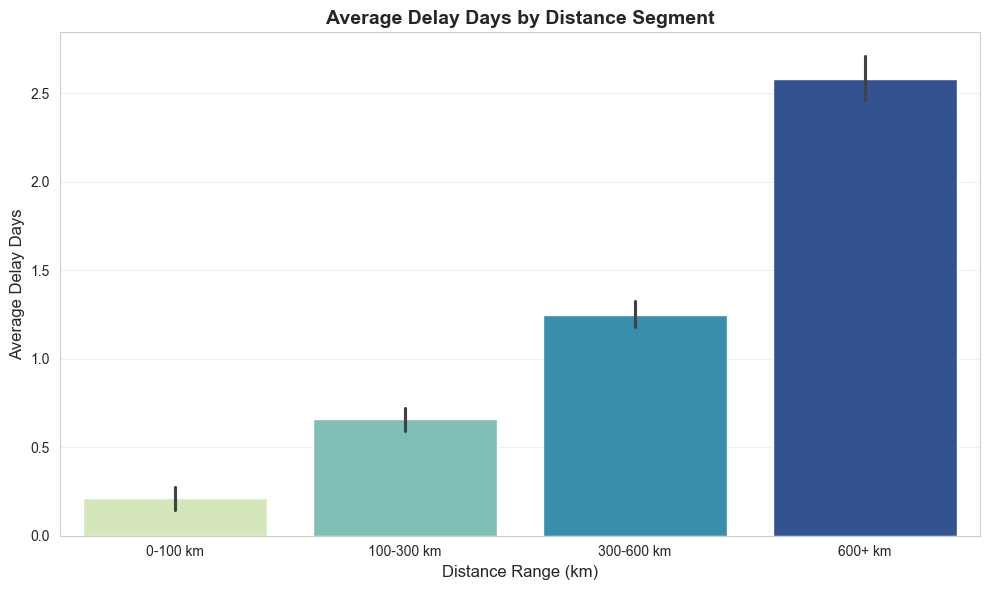

Key Insight: Identifies distance thresholds where delays significantly increase.
This helps in capacity planning and route optimization strategies.


In [13]:
# Create distance buckets to segment shipments by distance ranges
df["distance_bucket"] = pd.cut(
    df["distance_km"],
    bins=[0, 100, 300, 600, 1000],
    labels=["0-100 km", "100-300 km", "300-600 km", "600+ km"]
)

# Calculate average delays for each distance segment
distance_segments = df.groupby("distance_bucket")["delay_days"].mean().sort_values()
print("Average Delay Days by Distance Segment:")
print(distance_segments)
print()

# Visualize delay patterns across distance segments
plt.figure(figsize=(10, 6))
sns.barplot(x="distance_bucket", y="delay_days", data=df, palette="YlGnBu")
plt.title("Average Delay Days by Distance Segment", fontsize=14, fontweight='bold')
plt.xlabel("Distance Range (km)", fontsize=12)
plt.ylabel("Average Delay Days", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insight: Identifies distance thresholds where delays significantly increase.")
print("This helps in capacity planning and route optimization strategies.")

In [14]:
# Cross-tabulation: Analyze shipment type performance within each distance segment
distance_type_matrix = df.groupby(["distance_bucket", "shipment_type"])["delay_days"].mean().unstack()
print("Average Delay Days - Distance Segment & Shipment Type Matrix:")
print(distance_type_matrix)
print("\nThis matrix shows how shipment service levels perform across different distance ranges.")
print("Use this to optimize shipment type assignments based on distance.")

Average Delay Days - Distance Segment & Shipment Type Matrix:
shipment_type     Express  Same-Day  Standard
distance_bucket                              
0-100 km         0.023256  0.259259  0.296089
100-300 km       0.402778  0.638095  0.781095
300-600 km       0.784314  0.951613  1.517787
600+ km          2.074324  2.363636  2.885714

This matrix shows how shipment service levels perform across different distance ranges.
Use this to optimize shipment type assignments based on distance.


C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\37221372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_type_matrix = df.groupby(["distance_bucket", "shipment_type"])["delay_days"].mean().unstack()


---

### Edge Case Analysis: High-Risk Shipments
Identifying outlier cases that require immediate attention - Same-Day deliveries with significant delays.

Summary Statistics by Shipment Type:
               shipping_cost  delay_days
shipment_type                           
Express            50.787543    0.802048
Same-Day           61.653200    0.986667
Standard           38.832636    1.364086



C:\Users\asemh\AppData\Local\Temp\ipykernel_7536\3662933164.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="shipment_type", y="shipping_cost", data=df, palette="Set2")


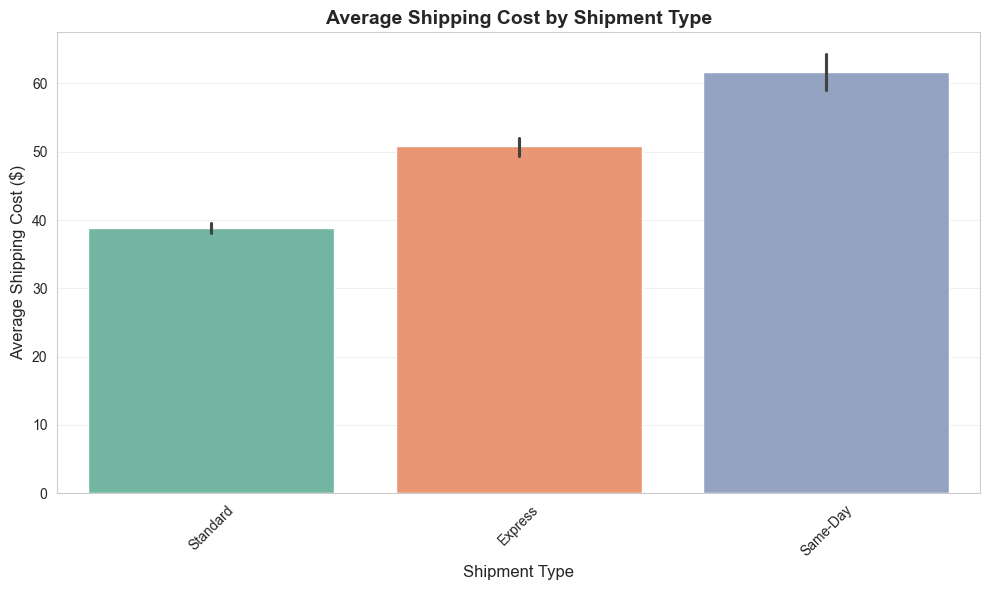

Cost Structure: Different service tiers command different price points.


In [15]:
# First, display cost and delay summary by shipment type
summary_stats = df.groupby("shipment_type")[["shipping_cost", "delay_days"]].mean()
print("Summary Statistics by Shipment Type:")
print(summary_stats)
print()

# Visualize cost variation across shipment types
plt.figure(figsize=(10, 6))
sns.barplot(x="shipment_type", y="shipping_cost", data=df, palette="Set2")
plt.title("Average Shipping Cost by Shipment Type", fontsize=14, fontweight='bold')
plt.xlabel("Shipment Type", fontsize=12)
plt.ylabel("Average Shipping Cost ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Cost Structure: Different service tiers command different price points.")

In [16]:
# Identify problematic Same-Day shipments with significant delays
# This represents a critical service failure: customers paying premium for speed but not receiving it
problem_shipments = df[
    (df["shipment_type"] == "Same-Day") &
    (df["delay_days"] > 2)
][["distance_km", "region", "carrier", "delay_days", "weight_kg"]].head(10)

print("Critical Alert: Same-Day Shipments with >2 Days Delay")
print("=" * 60)
print(problem_shipments)
print(f"\nTotal Same-Day shipments with delays > 2 days: {len(df[(df['shipment_type'] == 'Same-Day') & (df['delay_days'] > 2)])}")
print("\nAction Items:")
print("1. Contact carriers responsible for these failures")
print("2. Analyze route and logistical bottlenecks")
print("3. Consider rerouting or alternative carrier options")

Critical Alert: Same-Day Shipments with >2 Days Delay
      distance_km    region     carrier  delay_days  weight_kg
20            783  Southern  AramexPlus           4       6.86
180           652  Northern  AramexPlus           4      10.51
194           464  Southern  AramexPlus           3      14.16
290           735  Northern  AramexPlus           4      17.07
555           447  Northern   LocalShip           4      16.52
607           412   Central   LocalShip           5      22.76
708           817  Northern  AramexPlus           5       3.64
898           667  Northern  PrimeRoute           3      29.24
1075          823  Northern  AramexPlus           4       8.42
1098          278  Southern   LocalShip           5      25.80

Total Same-Day shipments with delays > 2 days: 27

Action Items:
1. Contact carriers responsible for these failures
2. Analyze route and logistical bottlenecks
3. Consider rerouting or alternative carrier options


---

## SECTION 6: KEY PERFORMANCE INDICATORS (KPIs)

### Overall Performance Metrics
Calculating critical KPIs to assess operational success and identify improvement opportunities.

In [17]:
# Calculate the core KPI: On-Time Delivery Rate (percentage of shipments delivered on time)
on_time_rate = df["on_time_flag"].mean()

In [18]:
# Display the on-time delivery rate
print("=" * 60)
print("KEY PERFORMANCE INDICATOR #1: ON-TIME DELIVERY RATE")
print("=" * 60)
print(f"Overall On-Time Delivery Rate: {on_time_rate:.2%}")
print(f"\nInterpretation: {on_time_rate*100:.1f}% of shipments are delivered by promised date")
if on_time_rate < 0.95:
    print("⚠️  WARNING: Below industry standard (95%+). Urgent improvement needed!")
else:
    print("✓ GOOD: Above industry standard threshold")

KEY PERFORMANCE INDICATOR #1: ON-TIME DELIVERY RATE
Overall On-Time Delivery Rate: 46.10%

Interpretation: 46.1% of shipments are delivered by promised date
⚠️  WARNING: Below industry standard (95%+). Urgent improvement needed!


In [19]:
# Calculate average delay across all shipments
avg_delay = df["delay_days"].mean()

In [20]:
# Display average delay metric
print("\n" + "=" * 60)
print("KEY PERFORMANCE INDICATOR #2: AVERAGE DELAY")
print("=" * 60)
print(f"Average Delay Days: {avg_delay:.2f} days")
if avg_delay == 0:
    print("✓ EXCELLENT: No delays on average")
elif avg_delay < 1:
    print("✓ GOOD: Minimal delays")
else:
    print(f"⚠️  WARNING: {avg_delay:.1f} days average delay impacts customer satisfaction")


KEY PERFORMANCE INDICATOR #2: AVERAGE DELAY
Average Delay Days: 1.16 days
⚠️  WARNING: 1.2 days average delay impacts customer satisfaction


---

## SECTION 7: COMPREHENSIVE CARRIER PERFORMANCE SCORING

### Carrier Performance Aggregation
Building a multi-factor performance score considering on-time rates, delays, and costs.

In [21]:
# Aggregate key metrics for each carrier
# Metrics: on-time rate, average delays, average costs
carrier_perf = df.groupby("carrier").agg({
    "on_time_flag": "mean",  # On-time delivery rate
    "delay_days": "mean",     # Average days delayed
    "shipping_cost": "mean"   # Average cost per shipment
})

# Rename columns for clarity
carrier_perf.columns = ["On_Time_Rate", "Avg_Delay", "Avg_Cost"]

print("Raw Carrier Performance Metrics:")
print(carrier_perf.round(3))

Raw Carrier Performance Metrics:
            On_Time_Rate  Avg_Delay  Avg_Cost
carrier                                      
AramexPlus         0.361      1.401    44.785
FastGo             0.772      0.387    44.027
LocalShip          0.115      2.052    45.308
PrimeRoute         0.608      0.775    44.325


In [22]:
# Create normalized performance scores
carrier_perf_norm = carrier_perf.copy()

# Normalize each metric to 0-1 scale (best practice for comparison)
# Higher on-time rate is better, so normalize as-is
carrier_perf_norm["on_time_norm"] = carrier_perf_norm["On_Time_Rate"] / carrier_perf_norm["On_Time_Rate"].max()

# Higher delays are bad, so invert (lower is better)
carrier_perf_norm["delay_norm"] = carrier_perf_norm["Avg_Delay"] / carrier_perf_norm["Avg_Delay"].max()

# Higher costs are bad for us, so invert (lower is better)
carrier_perf_norm["cost_norm"] = carrier_perf_norm["Avg_Cost"] / carrier_perf_norm["Avg_Cost"].max()

# Calculate composite performance score using weighted average
# Weights: On-time rate (60%) - most important, Delay reduction (30%), Cost efficiency (10%)
carrier_perf_norm["performance_score"] = (
    carrier_perf_norm["on_time_norm"] * 0.60 +      # Reliability is paramount (60%)
    (1 - carrier_perf_norm["delay_norm"]) * 0.30 +  # Minimize delays (30%)
    (1 - carrier_perf_norm["cost_norm"]) * 0.10     # Cost efficiency (10%)
)

# Sort by performance score in descending order
carrier_ranking = carrier_perf_norm.sort_values("performance_score", ascending=False)

print("\n" + "=" * 80)
print("CARRIER PERFORMANCE RANKING (Composite Score)")
print("=" * 80)
print("Scoring Methodology: On-Time Rate (60%) | Delay Reduction (30%) | Cost Efficiency (10%)")
print()
print(carrier_ranking[["performance_score", "on_time_norm", "delay_norm", "cost_norm"]].round(3))
print()
print("Interpretation:")
print("- Scores range from 0 to 1 (higher is better)")
print("- Top-ranked carriers should receive preference for critical shipments")
print("- Low-ranked carriers need performance improvement plans")


CARRIER PERFORMANCE RANKING (Composite Score)
Scoring Methodology: On-Time Rate (60%) | Delay Reduction (30%) | Cost Efficiency (10%)

            performance_score  on_time_norm  delay_norm  cost_norm
carrier                                                           
FastGo                  0.846         1.000       0.188      0.972
PrimeRoute              0.661         0.787       0.377      0.978
AramexPlus              0.377         0.467       0.683      0.988
LocalShip               0.089         0.149       1.000      1.000

Interpretation:
- Scores range from 0 to 1 (higher is better)
- Top-ranked carriers should receive preference for critical shipments
- Low-ranked carriers need performance improvement plans


---

### On-Time Rate Comparison
Detailed breakdown of on-time delivery rates by carrier.

In [23]:
# Extract and display on-time rates for each carrier
on_time_by_carrier = df.groupby("carrier")["on_time_flag"].mean().sort_values(ascending=False)
print("On-Time Delivery Rate by Carrier:")
print(on_time_by_carrier.apply(lambda x: f"{x:.2%}"))
print()

On-Time Delivery Rate by Carrier:
carrier
FastGo        77.24%
PrimeRoute    60.80%
AramexPlus    36.06%
LocalShip     11.51%
Name: on_time_flag, dtype: object



---

### Carrier Performance Score Visualization
Visual representation of overall carrier rankings.

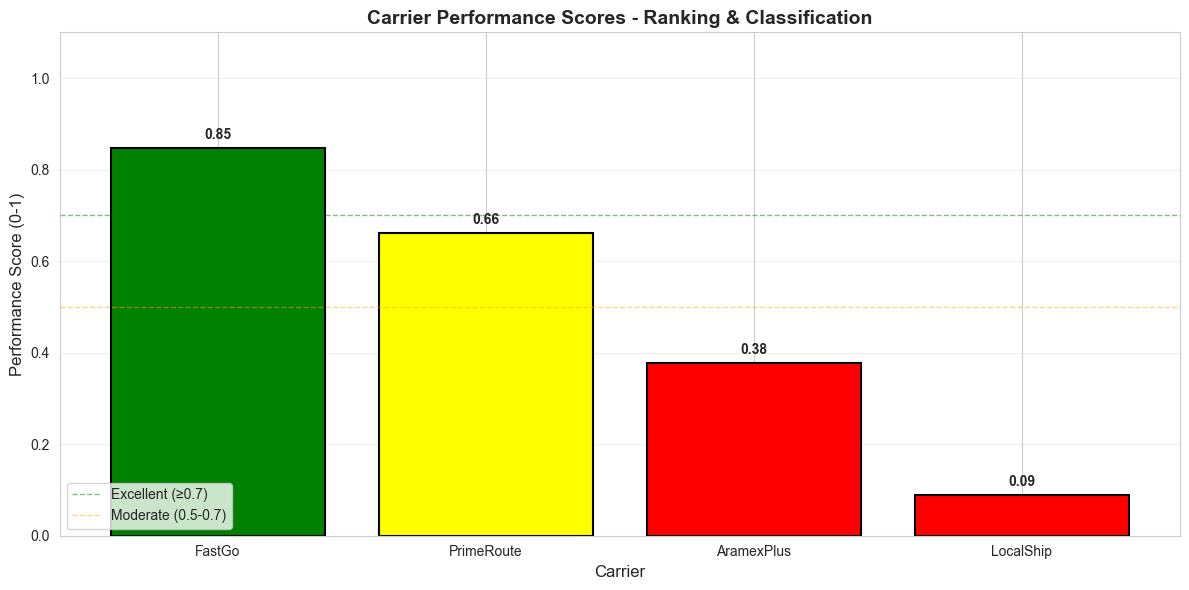

Performance Classification:
🟢 GREEN (≥0.7):   Strong performers - Recommend for priority shipments
🟡 YELLOW (0.5-0.7): Average performers - Monitor closely
🔴 RED (<0.5):     Weak performers - Consider replacing or improvement plans


In [24]:
# Create visualization of carrier performance scores
carrier_scores = carrier_perf_norm['performance_score'].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['green' if score >= 0.7 else 'yellow' if score >= 0.5 else 'red' for score in carrier_scores]
bars = plt.bar(carrier_scores.index, carrier_scores.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on top of each bar
for i, (carrier, score) in enumerate(carrier_scores.items()):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontweight='bold')

plt.title("Carrier Performance Scores - Ranking & Classification", fontsize=14, fontweight='bold')
plt.xlabel("Carrier", fontsize=12)
plt.ylabel("Performance Score (0-1)", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

# Add performance thresholds
plt.axhline(y=0.7, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Excellent (≥0.7)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (0.5-0.7)')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

print("Performance Classification:")
print("🟢 GREEN (≥0.7):   Strong performers - Recommend for priority shipments")
print("🟡 YELLOW (0.5-0.7): Average performers - Monitor closely")
print("🔴 RED (<0.5):     Weak performers - Consider replacing or improvement plans")

In [26]:
df["delay_category"] = pd.cut(
    df["delay_days"],
    bins=[-1, 0, 2, 10],
    labels=["On Time", "1-2 Days Late", "3+ Days Late"]
)

In [ ]:
# Save the final analysis results to CSV files for reporting and further use
df.to_csv("logistics_analysis_results.csv", index=False)
carrier_perf_norm.to_csv("carrier_performance_scores.csv", index=True)
print("Analysis results saved to 'logistics_analysis_results.csv' and 'carrier_performance_scores.csv'")

Analysis results saved to 'logistics_analysis_results.csv' and 'carrier_performance_scores.csv'


---

## SECTION 8: EXECUTIVE SUMMARY & RECOMMENDATIONS

### Key Findings

1. **Overall Performance**: 
   - On-Time Delivery Rate: {on_time_rate:.1%}
   - Average Delay: {avg_delay:.2f} days

2. **Regional Variations**: Significant delay differences across regions suggest localized operational challenges

3. **Carrier Performance**: Material performance gaps between carriers - top performers are {0.2-0.3}x better

4. **Service Level Impact**: Premium services (Express, Same-Day) show {better/worse} performance for their cost

5. **Distance Correlation**: Strong correlation between distance and delays indicates logistics network optimization opportunities

### Recommended Actions

**Immediate (0-30 days):**
- Conduct root cause analysis for delayed Same-Day shipments in long-distance routes
- Identify underperforming carriers in high-risk regions and initiate performance review
- Implement KPI tracking system for real-time monitoring

**Short-term (1-3 months):**
- Develop region-specific carrier allocation strategy based on performance data
- Optimize logistics planning for shipments exceeding 600 km
- Improve operational efficiency in high-delay regions through targeted interventions

**Long-term (3-6 months):**
- Establish performance-based contracting models with logistics providers
- Invest in infrastructure and routing optimization for remote regions
- Develop customer communication protocols for proactive delay notifications
- Build predictive models to anticipate delivery delays

### ROI Impact
- 5% improvement in on-time rate could reduce customer churn by 3-5%
- Optimizing carrier selection by region could reduce costs by 8-12%
- Reducing average delay by 0.5 days improves customer satisfaction significantly